<a href="https://colab.research.google.com/github/sdivyadarshini29-coder/DATA-SCIENCE-INTERNSHIP/blob/main/DIABETES_DATASET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
diabetes = load_diabetes()

In [3]:
data = load_diabetes(as_frame=True).frame


In [4]:
print("First 5 Rows:")
print(data.head())


First 5 Rows:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


In [5]:
print("\nShape of Dataset:")
print(data.shape)

print("\nStatistical Summary:")
print(data.describe())

print("\nDataset Info:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())


Shape of Dataset:
(442, 11)

Statistical Summary:
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.293722e-17  1.130318e-17   


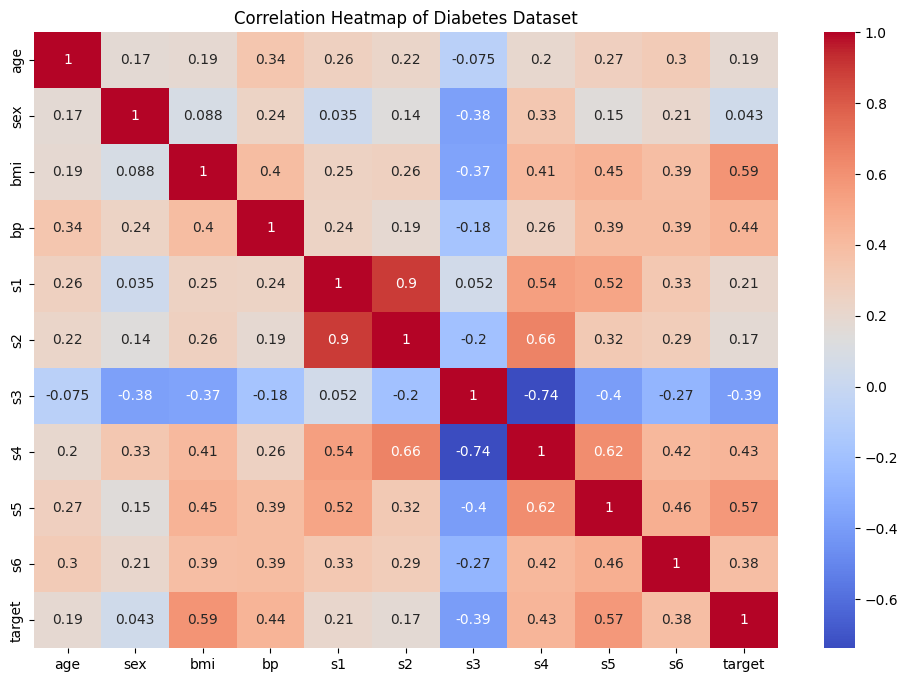

In [6]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Diabetes Dataset")
plt.show()

In [7]:
X = data.drop('target', axis=1)
y = data['target']


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaled Training Data:")
print(X_train_scaled)



Scaled Training Data:
[[ 1.49836523  1.06136988  0.21990201 ...  0.71103773  0.54748197
  -0.06144896]
 [-0.22885822  1.06136988 -0.41936607 ...  1.4842858  -0.01975653
   0.36723647]
 [ 0.08518241 -0.94217861  1.01898711 ... -0.06221033  0.3312366
  -0.31866022]
 ...
 [ 0.63475351 -0.94217861 -0.46502808 ... -0.83545839 -0.25375196
  -0.06144896]
 [-0.30736838 -0.94217861 -0.53352109 ... -0.06221033 -0.83072436
  -0.83308273]
 [-2.03459183 -0.94217861  0.56236706 ... -0.83545839 -0.13312789
  -0.06144896]]


In [10]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [11]:
y_pred = model.predict(X_test_scaled)

In [12]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nIntercept:")
print(model.intercept_)

print("\nCoefficients:")
print(model.coef_)

print("\nMean Squared Error:")
print(mse)

print("\nR² Score:")
print(r2)


Intercept:
153.73654390934846

Coefficients:
[  1.75375799 -11.51180908  25.60712144  16.82887167 -44.44885564
  24.64095356   7.67697768  13.1387839   35.16119521   2.35136365]

Mean Squared Error:
2900.1936284934804

R² Score:
0.4526027629719197


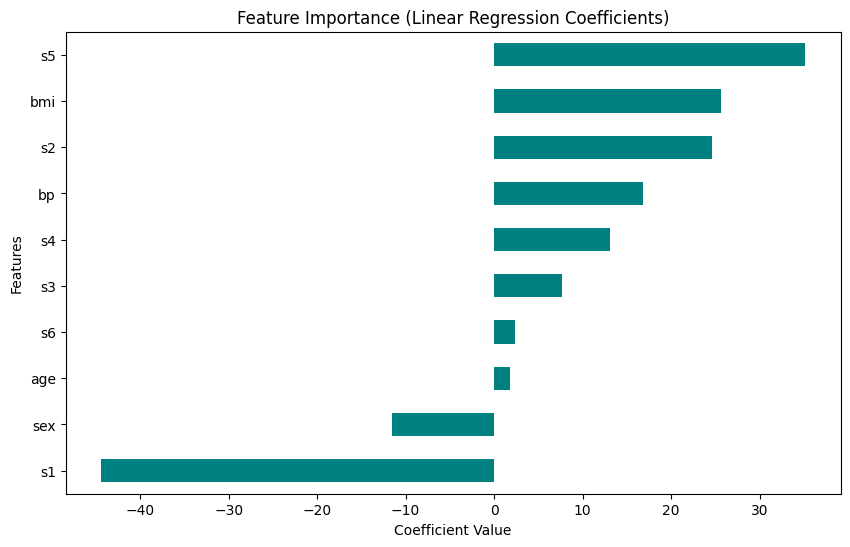

In [13]:
feature_importance = pd.Series(model.coef_, index=X.columns)

plt.figure(figsize=(10, 6))
feature_importance.sort_values().plot(kind='barh', color='teal')
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.show()


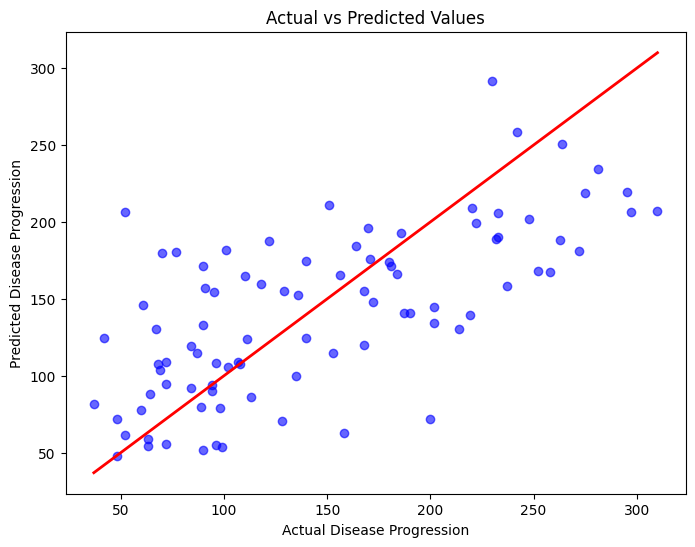

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)

# Perfect prediction line
plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)],
    color='red',
    linewidth=2
)
plt.xlabel("Actual Disease Progression")
plt.ylabel("Predicted Disease Progression")
plt.title("Actual vs Predicted Values")
plt.show()


In [15]:
sample_input = np.array([
    [0.05, -0.04, 0.06, 0.02, -0.03,
     -0.04, 0.01, -0.02, 0.04, 0.03]
])

# Scale sample input
sample_input_scaled = scaler.transform(sample_input)

# Predict
predicted_value = model.predict(sample_input_scaled)[0]

print(f"\nPredicted Disease Progression Value: {predicted_value:.2f}")


Predicted Disease Progression Value: 236.68


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
